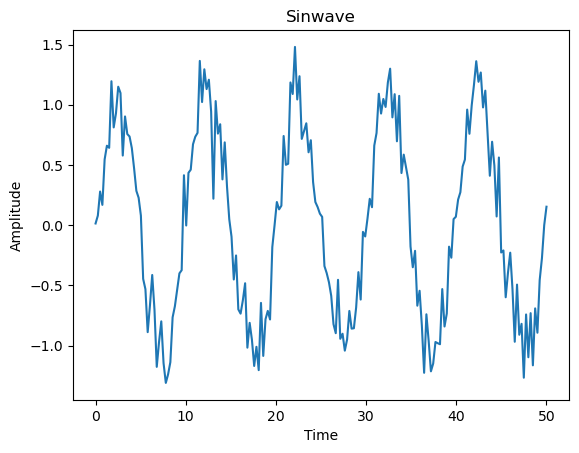

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

f = 0.1 
A = 1 
duration = 50 
fs = 200

rng = np.random.default_rng()

noise = rng.normal( loc = 0, scale = 0.2, size = 200)

t = np.linspace(0,duration, fs)

y = A*np.sin(2*np.pi*f*t) + noise

plt.plot(t,y)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()

In [4]:
import pmdarima as pm
model = pm.auto_arima(y, seasonal=False, information_criterion='aic',
                       stepwise=True, error_action='ignore',
                       suppress_warnings=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=462.576, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=91.312, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=317.033, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=70.975, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=65.638, Time=0.04 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=55.009, Time=0.07 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=38.353, Time=0.07 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-33.195, Time=0.25 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-22.635, Time=0.19 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=-20.244, Time=0.33 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.36 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=-34.393, Time=0.34 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=-20.560, Time=0.27 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=40.326, Time=0.12 

 Looks like autoarima found the same  result as we had in week 2, with ARIMA (2,0,0) giving us the lowest AIC and BIC. 
 

Let's test the auto arima on 3 different signals: Random walk, AR(2) process, and a temperature data set.


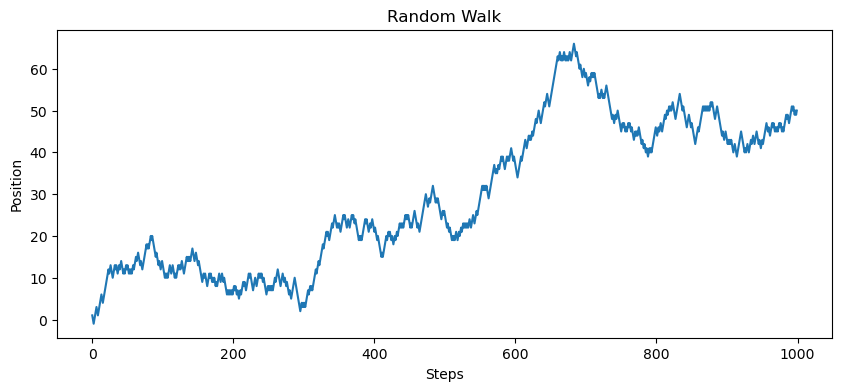

In [5]:
n_steps = 1000

steps = np.random.choice([-1,1], size = n_steps)

position = np.cumsum(steps)

plt.figure(figsize = (10,4))
plt.plot(position)
plt.title("Random Walk")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.show()

In [6]:
model = pm.auto_arima(position, seasonal=False, information_criterion='aic',
                       stepwise=True, error_action='ignore',
                       suppress_warnings=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2839.747, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2836.633, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2838.592, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2838.594, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2837.039, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2837.061, Time=0.32 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.499 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1416.316
Date:                Wed, 13 May 2026   AIC                           2836.633
Time:                        22:22:55   BIC                           2846.446
Sample:                             0   HQIC                          2840.363
          

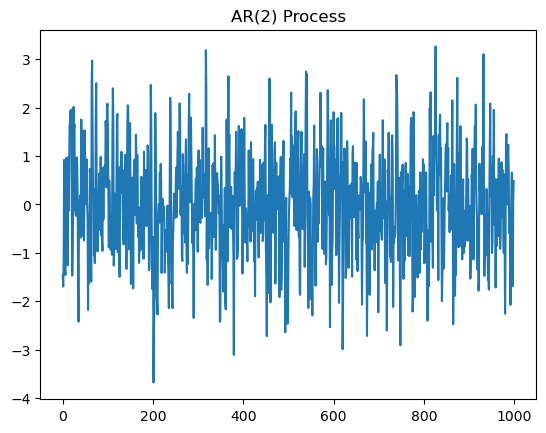

In [7]:
from statsmodels.tsa.arima_process import ArmaProcess

ar_coeffs = np.array([1,-0.5,0.2])
ma_coeffs = np.array([1])

ar2_process = ArmaProcess(ar_coeffs, ma_coeffs)
simulated_data = ar2_process.generate_sample(nsample=1000)

plt.plot(simulated_data)
plt.title("AR(2) Process")
plt.show()

In [8]:
model = pm.auto_arima(simulated_data, seasonal=False, information_criterion='aic',
                       stepwise=True, error_action='ignore',
                       suppress_warnings=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2795.917, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3001.012, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2828.774, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2799.054, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2800.447, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2795.856, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2799.007, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2794.346, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2796.102, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2796.184, Time=0.35 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=2796.346, Time=0.08 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 1.215 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1

In [9]:
fn = r"C:\Users\Jeff\Desktop\Research\Temperature.csv"

data = pd.read_csv(fn)

In [10]:
print(data.to_string())

     Longitude (x)  Latitude (y)      Station Name  Climate ID   Date/Time  Year  Month  Day  Data Quality  Max Temp (°C)  Max Temp Flag  Min Temp (°C)  Min Temp Flag  Mean Temp  Mean Temp Flag  Heat Deg Days (°C)  Heat Deg Days Flag  Cool Deg Days (°C)  Cool Deg Days Flag  Total Rain (mm) Total Rain Flag  Total Snow (cm) Total Snow Flag  Total Precip (mm) Total Precip Flag  Snow on Grnd (cm)  Snow on Grnd Flag  Dir of Max Gust (10s deg)  Dir of Max Gust Flag  Spd of Max Gust (km/h)  Spd of Max Gust Flag
0           -89.27         48.42  PORT ARTHUR CKPR     6046590  1963-01-01  1963      1    1           NaN           -2.8            NaN           -5.6            NaN       -4.2             NaN                22.2                 NaN                 0.0                 NaN              0.0             NaN              0.0               T                0.0                 T                NaN                NaN                        NaN                   NaN                     NaN   

array([<Axes: xlabel='Date/Time'>], dtype=object)

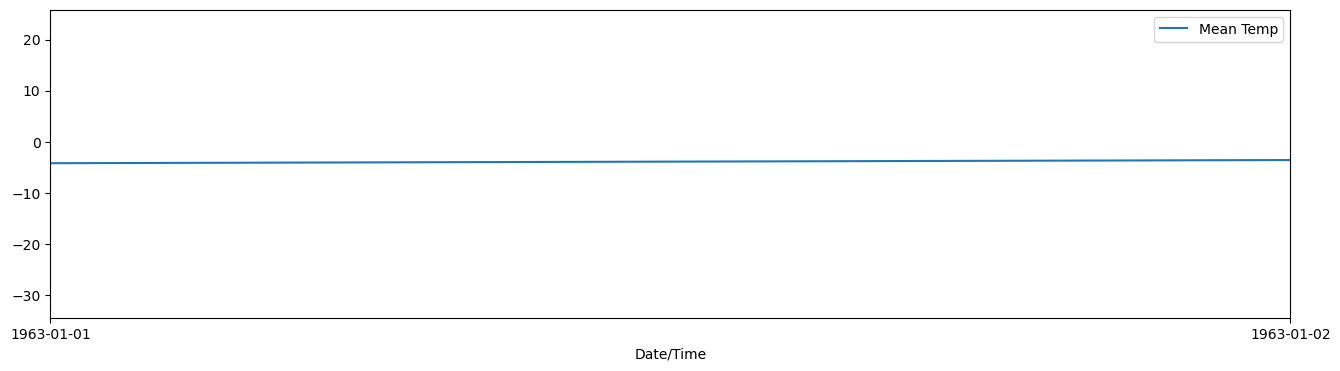

In [11]:
data.plot(x = 'Date/Time', y = 'Mean Temp', subplots = True, xlim = ('1963-01-01', '1963-06-30'), figsize =(16,4))

In [12]:
data['Date/Time'] = pd.to_datetime(data['Date/Time'])

array([<Axes: xlabel='Date/Time'>], dtype=object)

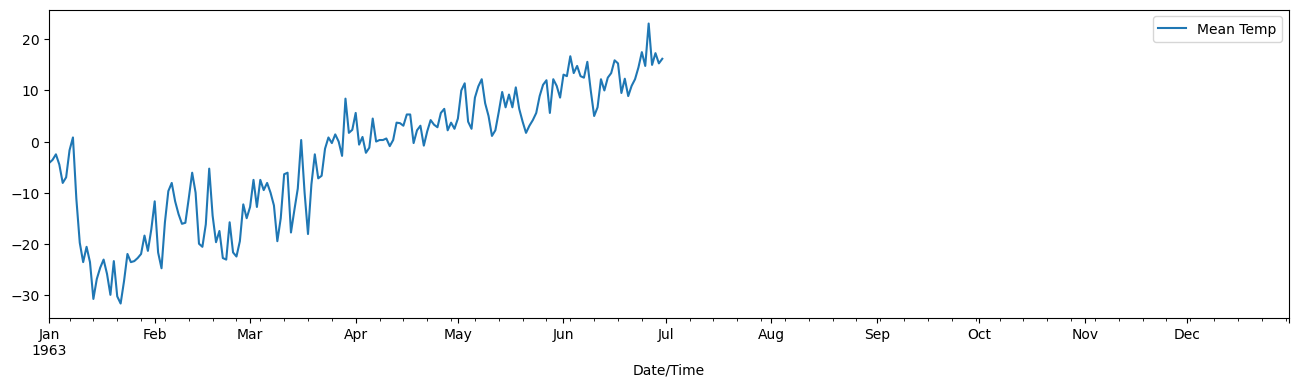

In [13]:
data.plot(x = 'Date/Time', y = 'Mean Temp', subplots = True, xlim = ('1963-01-01', '1963-12-31'), figsize =(16,4))

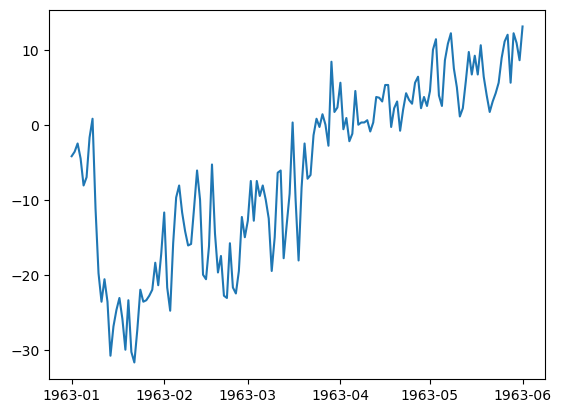

In [12]:
data = data.set_index('Date/Time')

series = data.loc['1963-01-01' : '1963-06-01' , 'Mean Temp']


plt.figure()
plt.plot(series.index,series)

In [13]:
model = pm.auto_arima(series, seasonal=False, information_criterion='aic',
                       stepwise=True, error_action='ignore',
                       suppress_warnings=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=866.458, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=892.095, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=893.155, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=888.619, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=890.189, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=870.075, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=865.217, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=880.029, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=868.307, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=866.917, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=865.505, Time=0.04 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=867.892, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=863.576, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=878.448, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=866.5

In [14]:
from  fit_arima_and_characterize import fit_arima_and_characterize 

In [15]:
fit_arima_and_characterize(y, "Sin wave")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=449.778, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=109.713, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=306.814, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=91.762, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=93.512, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=93.654, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=96.792, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=34.471, Time=0.15 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=8.063, Time=0.18 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=85.787, Time=0.05 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-7.832, Time=0.22 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=64.219, Time=0.05 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=9.920, Time=0.35 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=38.471, Time=0.29 sec

(ARIMA(order=(5, 0, 1), scoring_args={}, suppress_warnings=True),
 array([-0.16034019,  0.19722989,  0.26628354,  0.25117997,  0.13089017,
         0.08286148, -0.20215645,  0.12753731,  0.28656875,  0.31889204,
        -0.3906875 , -0.0316364 , -0.21630835, -0.10118527, -0.02040749,
         0.08589188, -0.28580681,  0.27846137, -0.02242949, -0.10264798,
         0.13366911, -0.05954697,  0.04152493,  0.32411264,  0.04396074,
        -0.09792253, -0.4212871 , -0.25940139,  0.23265913,  0.10489783,
        -0.22792313,  0.28809129, -0.34627804,  0.56527694, -0.3186733 ,
        -0.39426336, -0.19204188, -0.07172155,  0.17854153, -0.39912696,
         0.08435364,  0.2622943 ,  0.17471515,  0.29506816, -0.3305963 ,
        -0.20484309, -0.09663288,  0.27415463, -0.15088076, -0.21442841,
        -0.10146904,  0.08077556, -0.27942823,  0.03945933,  0.04893443,
        -0.27661505,  0.08369445, -0.30853989,  0.30551797,  0.13917569,
         0.2535366 , -0.28682226, -0.02465651, -0.27678302

In [ ]:
fit_arima_and_characterize(simulated_data, "Random Walk Process")

In [ ]:
fit_arima_and_characterize(simulated_data, "AR(2) Process")

In [14]:
from arima_utils import diagnostic_plot, fit_arima_and_characterize, characterize_residuals

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=462.576, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=91.312, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=317.033, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=70.975, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=65.638, Time=0.04 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=55.009, Time=0.08 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=38.353, Time=0.10 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-33.195, Time=0.26 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-22.635, Time=0.19 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=-20.244, Time=0.35 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.35 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=-34.393, Time=0.34 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=-20.560, Time=0.27 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=40.326, Time=0.12 

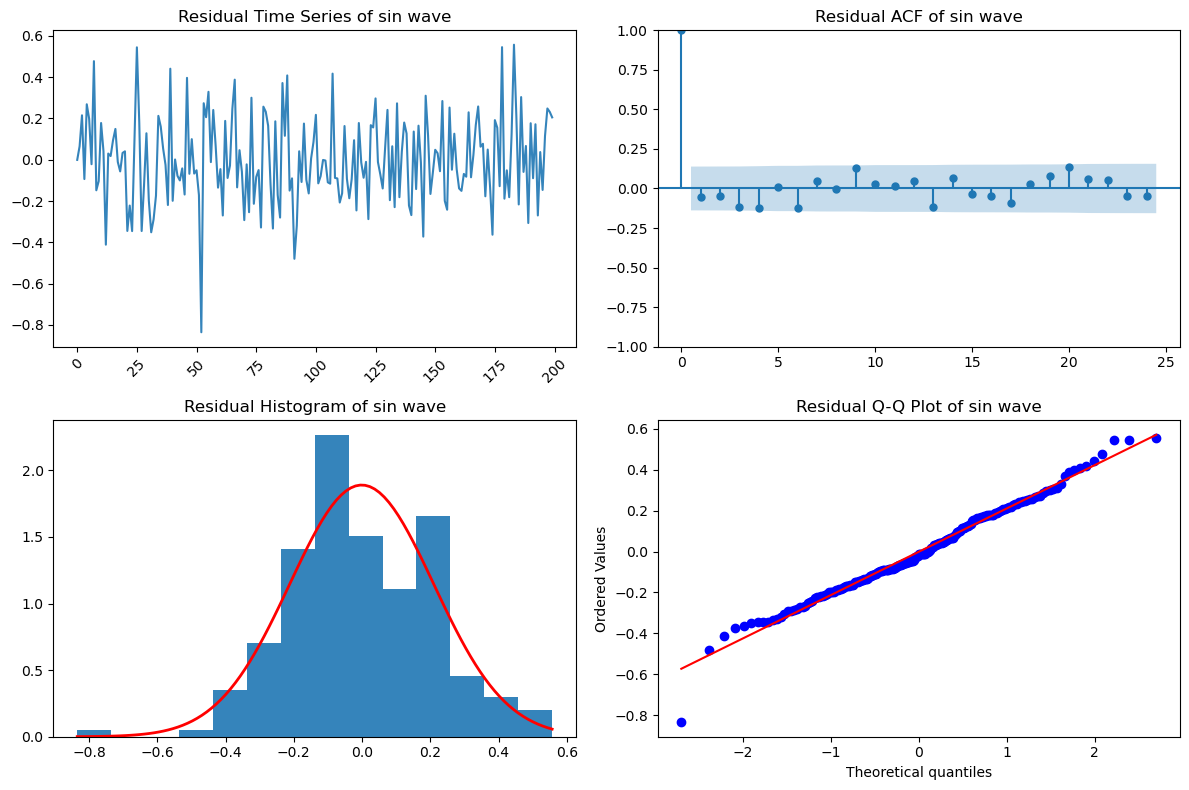

In [20]:
model, residuals, characterization, panel = fit_arima_and_characterize(y, title = "sin wave", plot = True)

In [25]:
print(characterization)

{'mean': -0.0010702484541595808, 'std': 0.2110590365570186, 'skew': 0.006851061631386872, 'kurtosis': 0.5874473110815059, 'shapiro_pvalue': 0.0685958694644085, 'ljung_box_pass': False, 'optimal_block_length': 1, 'recommended_method': 'Block Bootstrap is recommended'}


In [17]:
from sampling_methods import sample_gaussian, sample_kde, sample_block, sample_empirical

In [23]:
block_results = sample_block(residuals, 200, 1)

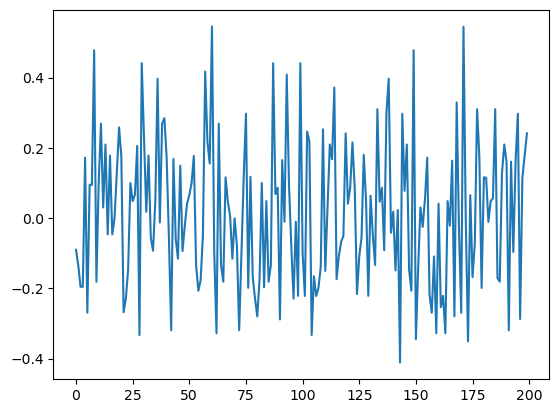

In [24]:
plt.plot(block_results)